# ODOP Analysis: Original vs Missing Dataset

## 1. Import Libraries

In [290]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [291]:
orig = pd.read_csv('ODOP.csv', encoding='latin1')
miss = pd.read_excel('ODOP missiing values.xlsx')

print("Original Shape:", orig.shape)
print("Missing Shape:", miss.shape)

Original Shape: (1241, 10)
Missing Shape: (1184, 10)


## 3. Original Dataset Analysis

In [292]:
orig.head()

,State,Product,District,LGD Code,Category,Sector,Description,GI Status,Photo,Ministry/ Department
0,Andaman and Nicobar Islands,Coconut & Coconut based products,Nicobars,603,Primary,Agriculture,The Nicobar Islands are known for their abunda...,No,https://drive.google.com/file/d/1ZKef7mLS4iub1...,Ministry of Agriculture & Farmers' Welfare
1,Andaman and Nicobar Islands,Fisheries/Marine products,North and Middle Andaman,632,Primary,Marine,"The North and Middle Andaman islands, are know...",No,https://drive.google.com/file/d/1caPuTWCA35HHL...,Department of Fisheries
2,Andaman and Nicobar Islands,Marine Products,South Andamans,602,Primary,Marine,"A delight for seafood enthusiasts, South Andam...",No,https://drive.google.com/file/d/15DIayCr05l903...,Department of Fisheries
3,Andhra Pradesh,Coffee (Araku),Alluri Sitarama Raju,745,Primary,Agriculture,Andhra Pradesh is one of the major coffee prod...,Yes,https://drive.google.com/file/d/18ptepDrMFsm5l...,Ministry of Agriculture & Farmers' Welfare
4,Andhra Pradesh,Bamboo Craft,Alluri Sitarama Raju,745,Secondary,Handicraft,Crafted with finesse in Andhra Pradesh's Allur...,No,https://drive.google.com/file/d/1HT-KGuEaGPfvf...,DC Handicraft


In [293]:
orig.tail()

,State,Product,District,LGD Code,Category,Sector,Description,GI Status,Photo,Ministry/ Department
1236,West Bengal,Leather Goods,South 24 Parganas,304,Primary,Handicraft,These goods from South 24 Parganas are made us...,No,https://drive.google.com/file/d/1Egvs839YLMYIJ...,DC Handicraft
1237,West Bengal,Marine Products,South 24 Parganas,304,Secondary,Marine,Marine products from this region are products ...,No,https://drive.google.com/file/d/1ZPCJu2lpe93f9...,Department of fisheries
1238,West Bengal,Sundarban Honey,South 24 Parganas,304,Tertiary,Agriculture,Sundarban honey is considered to be one of the...,Yes,https://drive.google.com/file/d/1IoIq_P8mQU--3...,Ministry of Agriculture & Farmers' Welfare
1239,West Bengal,Tulai Panji Rice (Aromatic Rice),Uttar Dinajpur (North Dinajpur),311,Primary,Agriculture,"Uttar Dinajpur is known for the Tulai Panji, a...",Yes,https://drive.google.com/file/d/1sBvpn8m-KydSl...,Ministry of Agriculture & Farmers' Welfare
1240,West Bengal,Jute diversified products,Uttar Dinajpur (North Dinajpur),311,Secondary,Handicraft,Jute is a natural fiber that is obtained from ...,No,https://drive.google.com/file/d/1H_A6ik3z2cTyH...,DC Handicraft


In [294]:
orig.info()

<class 'pandas.DataFrame'>
RangeIndex: 1241 entries, 0 to 1240
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   State                 1241 non-null   str  
 1   Product               1241 non-null   str  
 2   District              1241 non-null   str  
 3   LGD Code              1241 non-null   int64
 4   Category              1241 non-null   str  
 5   Sector                1241 non-null   str  
 6   Description           1241 non-null   str  
 7   GI Status             1241 non-null   str  
 8   Photo                 1241 non-null   str  
 9   Ministry/ Department  1241 non-null   str  
dtypes: int64(1), str(9)
memory usage: 97.1 KB


In [295]:
orig.isnull().sum()

State                   0
Product                 0
District                0
LGD Code                0
Category                0
Sector                  0
Description             0
GI Status               0
Photo                   0
Ministry/ Department    0
dtype: int64

The dataset contains mostly categorical variables. No missing values were observed in the original dataset.

In [296]:
print(orig.dtypes)


State                     str
Product                   str
District                  str
LGD Code                int64
Category                  str
Sector                    str
Description               str
GI Status                 str
Photo                     str
Ministry/ Department      str
dtype: object


In [297]:
cat_cols = orig.select_dtypes(include='object').columns
num_cols = orig.select_dtypes(exclude='object').columns

print("Categorical Columns:\n", cat_cols)
print("\nNumerical Columns:\n", num_cols)

Categorical Columns:
 Index(['State', 'Product', 'District', 'Category', 'Sector', 'Description',
       'GI Status', 'Photo', 'Ministry/ Department'],
      dtype='str')

Numerical Columns:
 Index(['LGD Code'], dtype='str')


C:\Users\Chetan\AppData\Local\Temp\ipykernel_12944\2802027277.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = orig.select_dtypes(include='object').columns


### Data Type Identification

The dataset consists of predominantly categorical variables such as State, Product, District, Category, and Sector, which represent qualitative attributes.

Only one numerical column (LGD Code) is present, which serves as an identifier rather than a quantitative feature.

Therefore, the analysis primarily focuses on categorical data patterns and relationships.

In [298]:
orig[cat_cols].nunique().sort_values(ascending=False)

Description             1239
Photo                   1173
Product                  850
District                 781
State                     36
Ministry/ Department      30
Sector                    14
GI Status                  9
Category                   6
dtype: int64

### Inconsistency in Categorical Data

During exploratory data analysis, it was observed that several categorical columns in the dataset contain inconsistencies. These inconsistencies arise due to variations in text formatting such as differences in capitalization, extra spaces, and hidden characters.

Such issues can lead to multiple representations of the same category, which may affect the accuracy of analysis and visualizations.

To illustrate this problem:

- The **Category** column shows **6 unique values**, whereas it is expected to have only a limited number of categories such as Primary, Secondary, and Tertiary.
- The **GI Status** column shows **9 unique values**, even though it should ideally contain only two values: "Yes" and "No".

These discrepancies indicate that the same categories are represented in multiple formats.

To resolve this, categorical variables were standardized by trimming whitespace and applying consistent text formatting. This helped in reducing duplicate representations and improving overall data quality.

In [299]:
print(orig['Category'].unique())
print(orig['Category'].value_counts())

<StringArray>
['Primary', 'Secondary', 'Tertiary', 'Others', 'primary', 'Secondary ']
Length: 6, dtype: str
Category
Primary       775
Secondary     313
Tertiary      103
Others         48
primary         1
Secondary       1
Name: count, dtype: int64


In [300]:
print(orig['GI Status'].unique())
print(orig['GI Status'].value_counts())

<StringArray>
['No', 'Yes', 'no ', 'NO ', 'yes ', 'No ', 'yes', 'no', 'Yes ']
Length: 9, dtype: str
GI Status
No      945
Yes     249
no       15
No       13
NO       10
yes       3
yes       2
no        2
Yes       2
Name: count, dtype: int64


In [301]:
import re

# Clean column names
orig.columns = orig.columns.str.strip()

# Function for strong cleaning
def clean_text(x):
    if isinstance(x, str):
        x = x.replace('\xa0', ' ')      # remove hidden spaces
        x = re.sub(r'\s+', ' ', x)      # remove extra spaces
        x = x.strip().lower()           # lowercase
        x = x.title()                   # proper format (Title Case)
    return x

# Apply on categorical columns
cols = ['State', 'District', 'Category', 'Sector','GI Status','Ministry/ Department']

for col in cols:
    orig[col] = orig[col].apply(clean_text)

# Remove duplicates
orig.drop_duplicates(inplace=True)


In [302]:
orig[cat_cols].nunique().sort_values(ascending=False)

Description             1239
Photo                   1173
Product                  850
District                 781
State                     36
Ministry/ Department      27
Sector                    10
Category                   4
GI Status                  2
dtype: int64

In [303]:
print(orig['Category'].unique())
print(orig['Category'].value_counts())

<StringArray>
['Primary', 'Secondary', 'Tertiary', 'Others']
Length: 4, dtype: str
Category
Primary      776
Secondary    314
Tertiary     103
Others        48
Name: count, dtype: int64


In [304]:
print(orig['GI Status'].unique())
print(orig['GI Status'].value_counts())

<StringArray>
['No', 'Yes']
Length: 2, dtype: str
GI Status
No     985
Yes    256
Name: count, dtype: int64


In [305]:
orig['State'].value_counts().head(10)
orig['Category'].value_counts()

pd.crosstab(orig['State'], orig['Category'])

Category,Others,Primary,Secondary,Tertiary
State,,,,
Andaman And Nicobar Islands,0,3,0,0
Andhra Pradesh,26,26,26,21
Arunachal Pradesh,0,25,0,0
Assam,0,38,3,0
Bihar,0,38,33,16
Chandigarh,0,1,0,0
Chhattisgarh,0,33,5,0
Dadra & Nagar Haveli (Ut) Daman & Diu (Ut),0,3,0,0
Delhi,0,11,1,0


## 4. Original Visualization

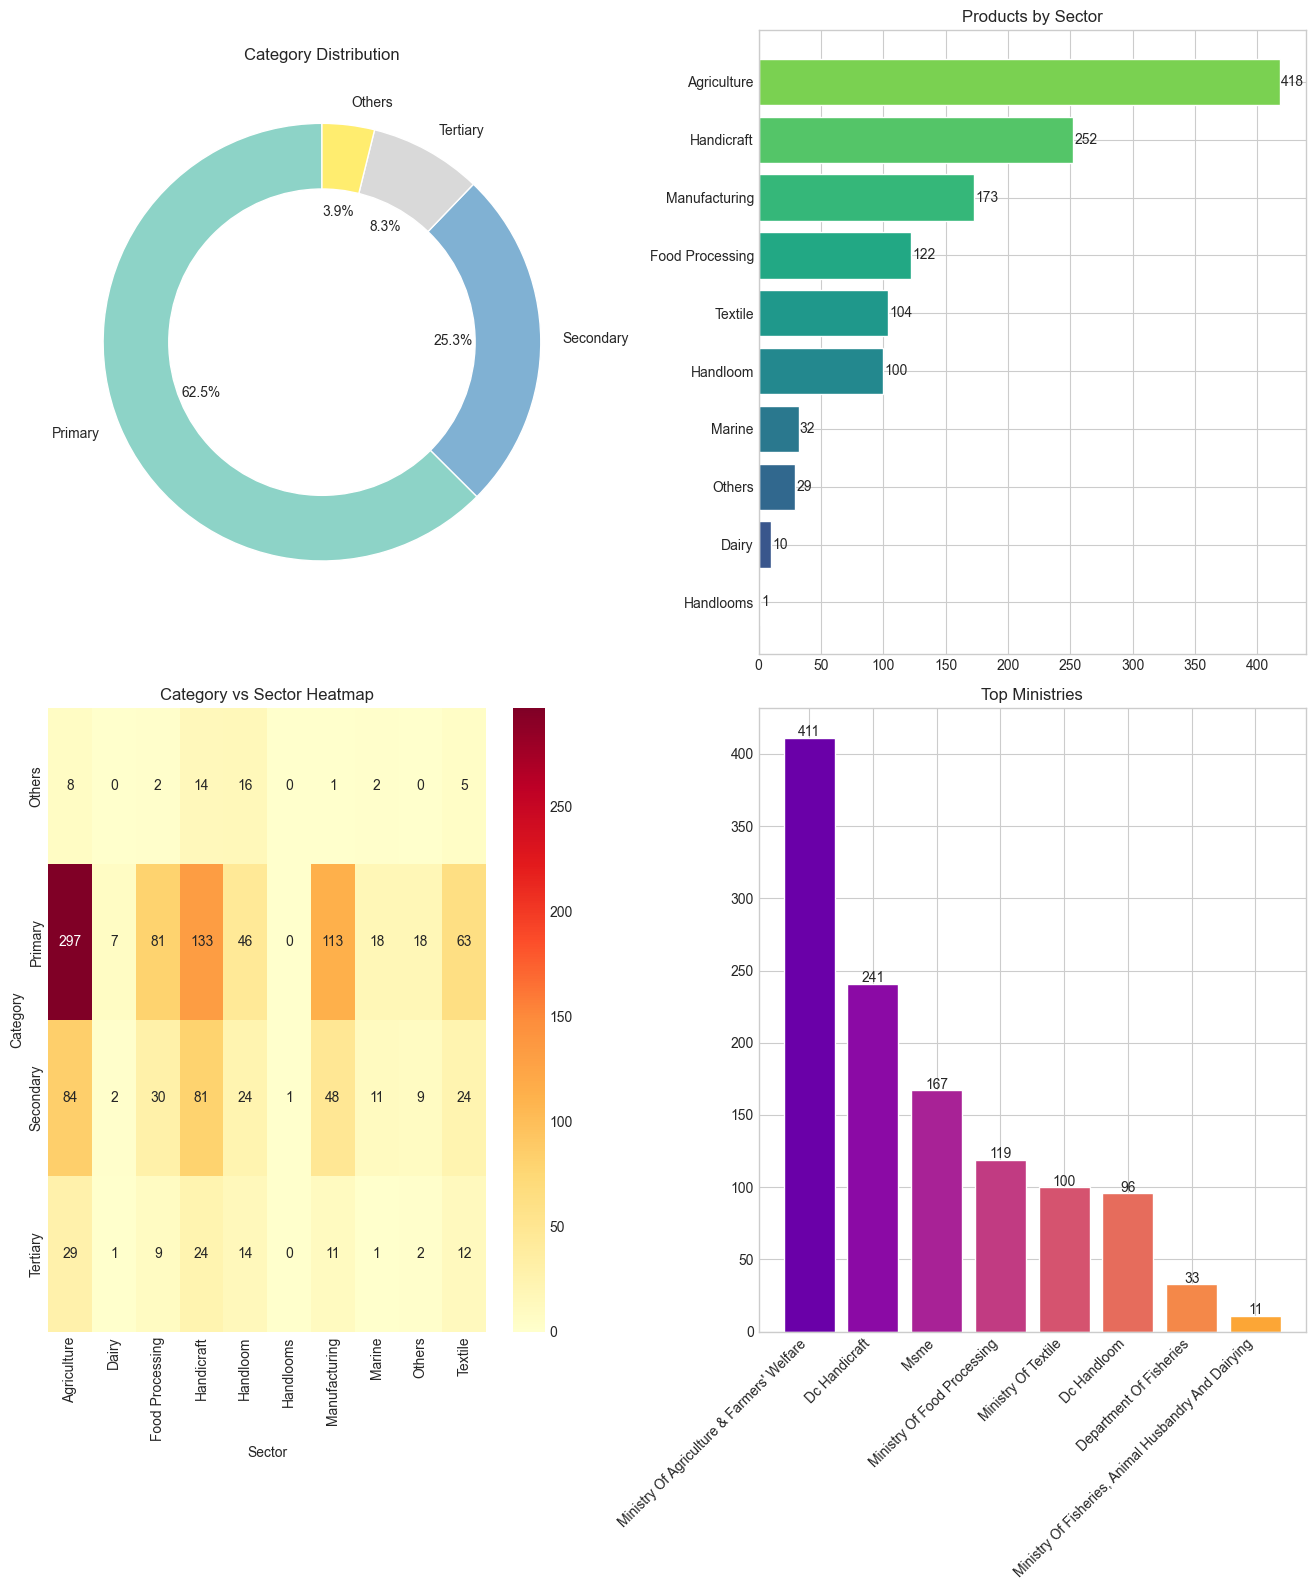

In [306]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

plt.figure(figsize=(20, 16))


plt.subplot(2, 3, 2)

category_counts = orig['Category'].value_counts()

wedges, texts, autotexts = plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Category Distribution")


plt.subplot(2, 3, 3)

sector_counts = orig['Sector'].value_counts()

bars = plt.barh(sector_counts.index[::-1], sector_counts.values[::-1],
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(sector_counts))))

for bar, val in zip(bars, sector_counts.values[::-1]):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.title("Products by Sector")






plt.subplot(2, 3, 5)

heatmap_data = pd.crosstab(orig['Category'], orig['Sector'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd')

plt.title("Category vs Sector Heatmap")

plt.subplot(2, 3, 6)

ministry_counts = orig['Ministry/ Department'].value_counts().head(8)

bars = plt.bar(range(len(ministry_counts)), ministry_counts.values,
               color=plt.cm.plasma(np.linspace(0.2, 0.8, len(ministry_counts))))

plt.xticks(range(len(ministry_counts)), ministry_counts.index, rotation=45, ha='right')

for bar, val in zip(bars, ministry_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, str(val), ha='center')

plt.title("Top Ministries")



plt.tight_layout()
plt.savefig("ODOP_Original_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

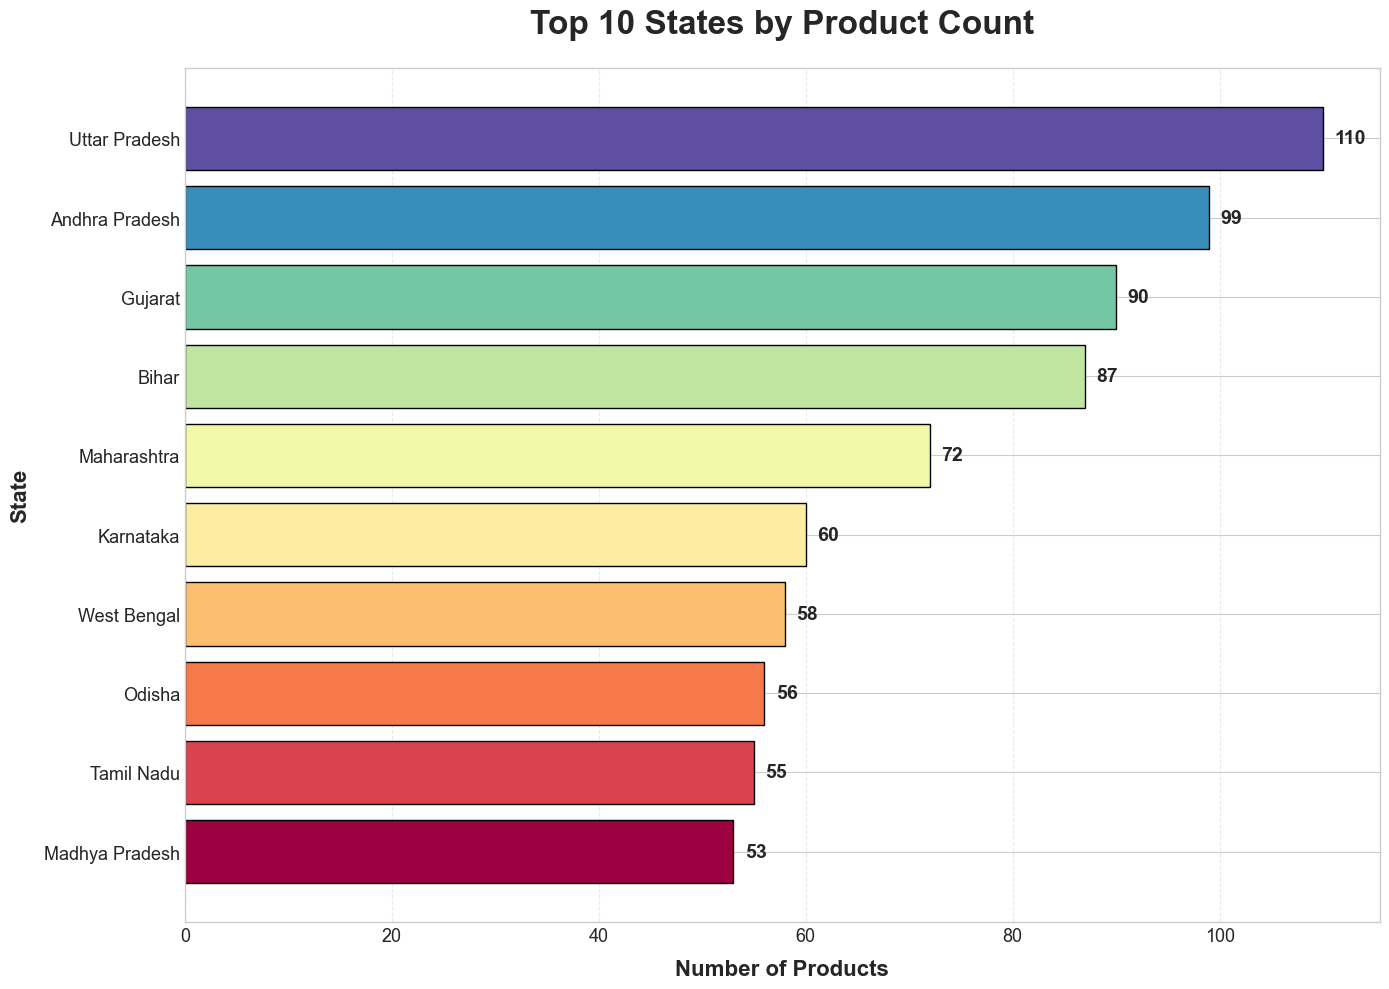

In [307]:
import matplotlib.pyplot as plt
import numpy as np

# 🔥 BIGGER FIGURE
plt.figure(figsize=(14, 10))

state_counts = orig['State'].value_counts().head(10)

bars = plt.barh(
    state_counts.index[::-1],
    state_counts.values[::-1],
    color=plt.cm.Spectral(np.linspace(0, 1, len(state_counts))),
    edgecolor='black'   # 🔥 adds sharp look
)

# 🔥 VALUE LABELS (BETTER POSITIONING)
for bar, val in zip(bars, state_counts.values[::-1]):
    plt.text(val + max(state_counts.values)*0.01,
             bar.get_y() + bar.get_height()/2,
             str(val),
             va='center',
             fontsize=14,
             fontweight='bold')

# 🔥 TITLE (CENTER + SPACING)
plt.title(
    "Top 10 States by Product Count",
    fontsize=24,
    fontweight='bold',
    pad=25
)

# 🔥 AXIS LABELS
plt.xlabel("Number of Products", fontsize=16, fontweight='bold', labelpad=10)
plt.ylabel("State", fontsize=16, fontweight='bold', labelpad=10)

# 🔥 TICKS
plt.xticks(fontsize=13)
plt.yticks(fontsize=13)

# 🔥 GRID
plt.grid(axis='x', linestyle='--', alpha=0.4)

# 🔥 REMOVE EXTRA MARGINS
plt.tight_layout()

# 🔥 HIGH QUALITY SAVE
plt.savefig("Top_States_Big.png", dpi=300, bbox_inches='tight')

plt.show()

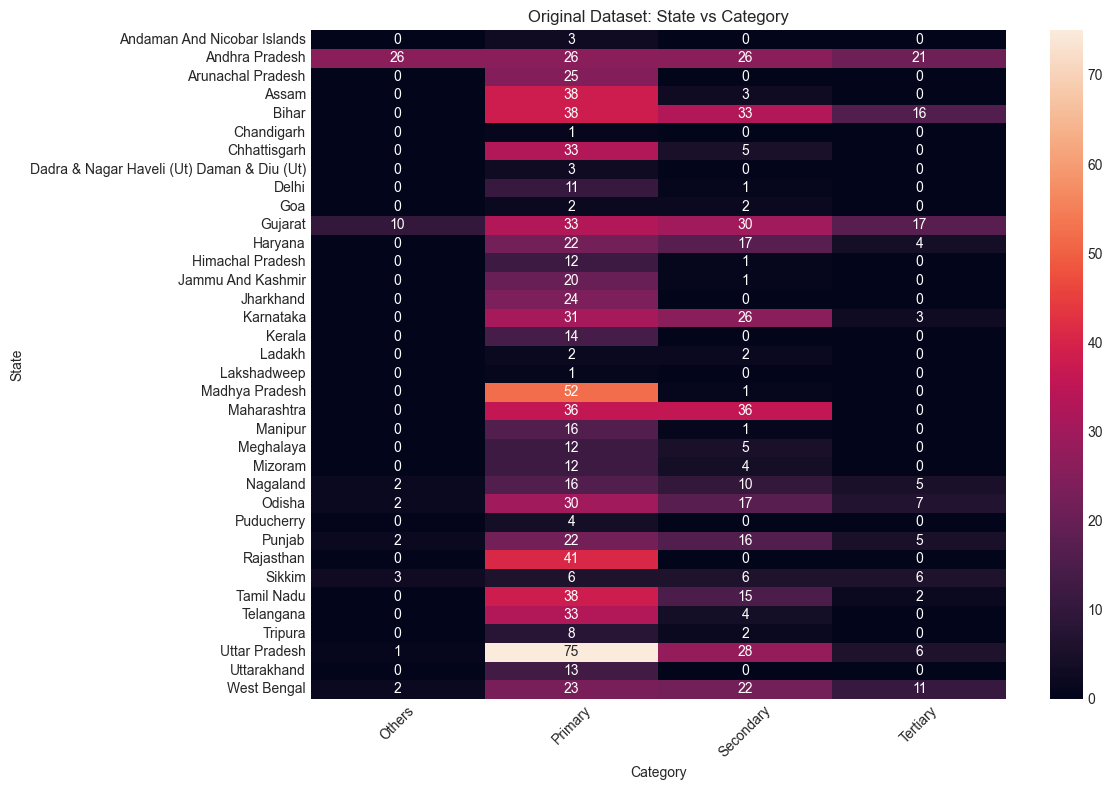

In [308]:
pivot_orig = pd.crosstab(orig['State'], orig['Category'])

plt.figure(figsize=(12,8))  # bigger size

sns.heatmap(pivot_orig, annot=True, fmt='d')  # show numbers

plt.title("Original Dataset: State vs Category")
plt.xlabel("Category")
plt.ylabel("State")

plt.xticks(rotation=45)
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

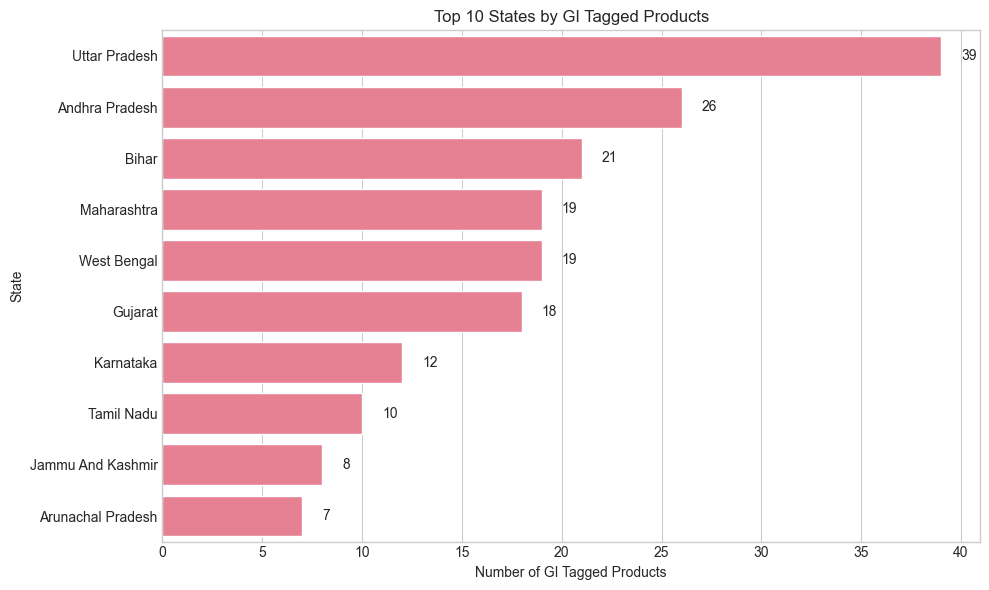

In [309]:

# Count GI = Yes per state
gi_state = orig[orig['GI Status'] == 'Yes']['State'].value_counts().head(10)

plt.figure(figsize=(10,6))

# Horizontal barplot
ax = sns.barplot(x=gi_state.values, y=gi_state.index)

# Add values
for i, v in enumerate(gi_state.values):
    ax.text(v + 1, i, str(v), va='center')

plt.title("Top 10 States by GI Tagged Products")
plt.xlabel("Number of GI Tagged Products")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## 5. Missing Dataset Analysis

In [310]:
miss.head()

,State,Product,District,LGD Code,Category,Sector,Description,GI Status,Photo,Ministry/ Department
0,Andaman and Nicobar Islands,Coconut & Coconut based products,Nicobars,603.0,Primary,Agriculture,The Nicobar Islands are known for their abunda...,No,https://drive.google.com/file/d/1ZKef7mLS4iub1...,Ministry of Agriculture & Farmers' Welfare
1,Andaman and Nicobar Islands,Fisheries/Marine products,North and Middle Andaman,632.0,Primary,Marine,"The North and Middle Andaman islands, are know...",No,https://drive.google.com/file/d/1caPuTWCA35HHL...,Department of Fisheries
2,Andaman and Nicobar Islands,Marine Products,South Andamans,602.0,Primary,Marine,"A delight for seafood enthusiasts, South Andam...",No,https://drive.google.com/file/d/15DIayCr05l903...,Department of Fisheries
3,Andhra Pradesh,Coffee (Araku),Alluri Sitarama Raju,745.0,Primary,Agriculture,Andhra Pradesh is one of the major coffee prod...,Yes,https://drive.google.com/file/d/18ptepDrMFsm5l...,Ministry of Agriculture & Farmers' Welfare
4,Andhra Pradesh,Bamboo Craft,Alluri Sitarama Raju,745.0,Secondary,Handicraft,Crafted with finesse in Andhra Pradesh's Allur...,No,https://drive.google.com/file/d/1HT-KGuEaGPfvf...,DC Handicraft


In [311]:
miss.info()

<class 'pandas.DataFrame'>
RangeIndex: 1184 entries, 0 to 1183
Data columns (total 10 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   State                 1183 non-null   str    
 1   Product               1183 non-null   str    
 2   District              1182 non-null   str    
 3   LGD Code              1178 non-null   float64
 4   Category              1177 non-null   str    
 5   Sector                1181 non-null   str    
 6   Description           1182 non-null   str    
 7   GI Status             1166 non-null   str    
 8   Photo                 1183 non-null   str    
 9   Ministry/ Department  1181 non-null   str    
dtypes: float64(1), str(9)
memory usage: 92.6 KB


In [312]:
miss.isnull().sum()

State                    1
Product                  1
District                 2
LGD Code                 6
Category                 7
Sector                   3
Description              2
GI Status               18
Photo                    1
Ministry/ Department     3
dtype: int64

In [313]:
miss[cat_cols].nunique().sort_values(ascending=False)

Description             1180
Photo                   1117
Product                  807
District                 746
State                     35
Ministry/ Department      29
Sector                    14
GI Status                  9
Category                   6
dtype: int64

## 6. Cleaning Missing Dataset

In [314]:
import re

# 1. Clean column names
miss.columns = miss.columns.str.strip()

# 2. Cleaning function
def clean_text(x):
    if isinstance(x, str):
        x = x.replace('\xa0', ' ')
        x = re.sub(r'\s+', ' ', x)
        x = x.strip().lower()
        x = x.title()
    return x

# 3. Apply cleaning to categorical columns


for col in cols:
    miss[col] = miss[col].apply(clean_text)

# 4. Handle ALL missing values properly

# Categorical columns
miss['Sector'] = miss['Sector'].fillna('Unknown')
miss['GI Status'] = miss['GI Status'].fillna('Not Available')
miss['Ministry/ Department'] = miss['Ministry/ Department'].fillna('Unknown')
miss['Photo'] = miss['Photo'].fillna('No Image')
miss['State'] = miss['State'].fillna('Unknown State')
miss['Product'] = miss['Product'].fillna('Unknown Product')
miss['District'] = miss['District'].fillna('Unknown District')
miss['Category'] = miss['Category'].fillna('Unknown Category')
miss['Description'] = miss['Description'].fillna('No Description Available')

# Numerical column
miss['LGD Code'] = miss['LGD Code'].fillna(miss['LGD Code'].median())

# 5. Remove duplicates
miss.drop_duplicates(inplace=True)

# 6. Final check
miss.isnull().sum()

State                   0
Product                 0
District                0
LGD Code                0
Category                0
Sector                  0
Description             0
GI Status               0
Photo                   0
Ministry/ Department    0
dtype: int64

In [315]:
# Find most frequent state
state_mode = miss['State'].mode()[0]

# Replace Unknown State
miss['State'] = miss['State'].replace('Unknown State', state_mode)
# Impute Category based on the mode of its Sector
miss['Category'] = miss.groupby('Sector')['Category'].transform(
    lambda x: x.fillna(x.mode()[0] if not x.mode().empty else "Unknown")
)
# Sector
sector_mode = miss['Sector'].mode()[0]
miss['Sector'] = miss['Sector'].replace('Unknown', sector_mode)

# GI Status
gi_mode = miss['GI Status'].mode()[0]
miss['GI Status'] = miss['GI Status'].replace('Not Available', gi_mode)

# Ministry/ Department
ministry_mode = miss['Ministry/ Department'].mode()[0]
miss['Ministry/ Department'] = miss['Ministry/ Department'].replace('Unknown', ministry_mode)





In [316]:
miss[cat_cols].nunique().sort_values(ascending=False)

Description             1181
Photo                   1118
Product                  808
District                 747
State                     35
Ministry/ Department      26
Sector                    10
Category                   5
GI Status                  2
dtype: int64

## 7. Visualization After Cleaning

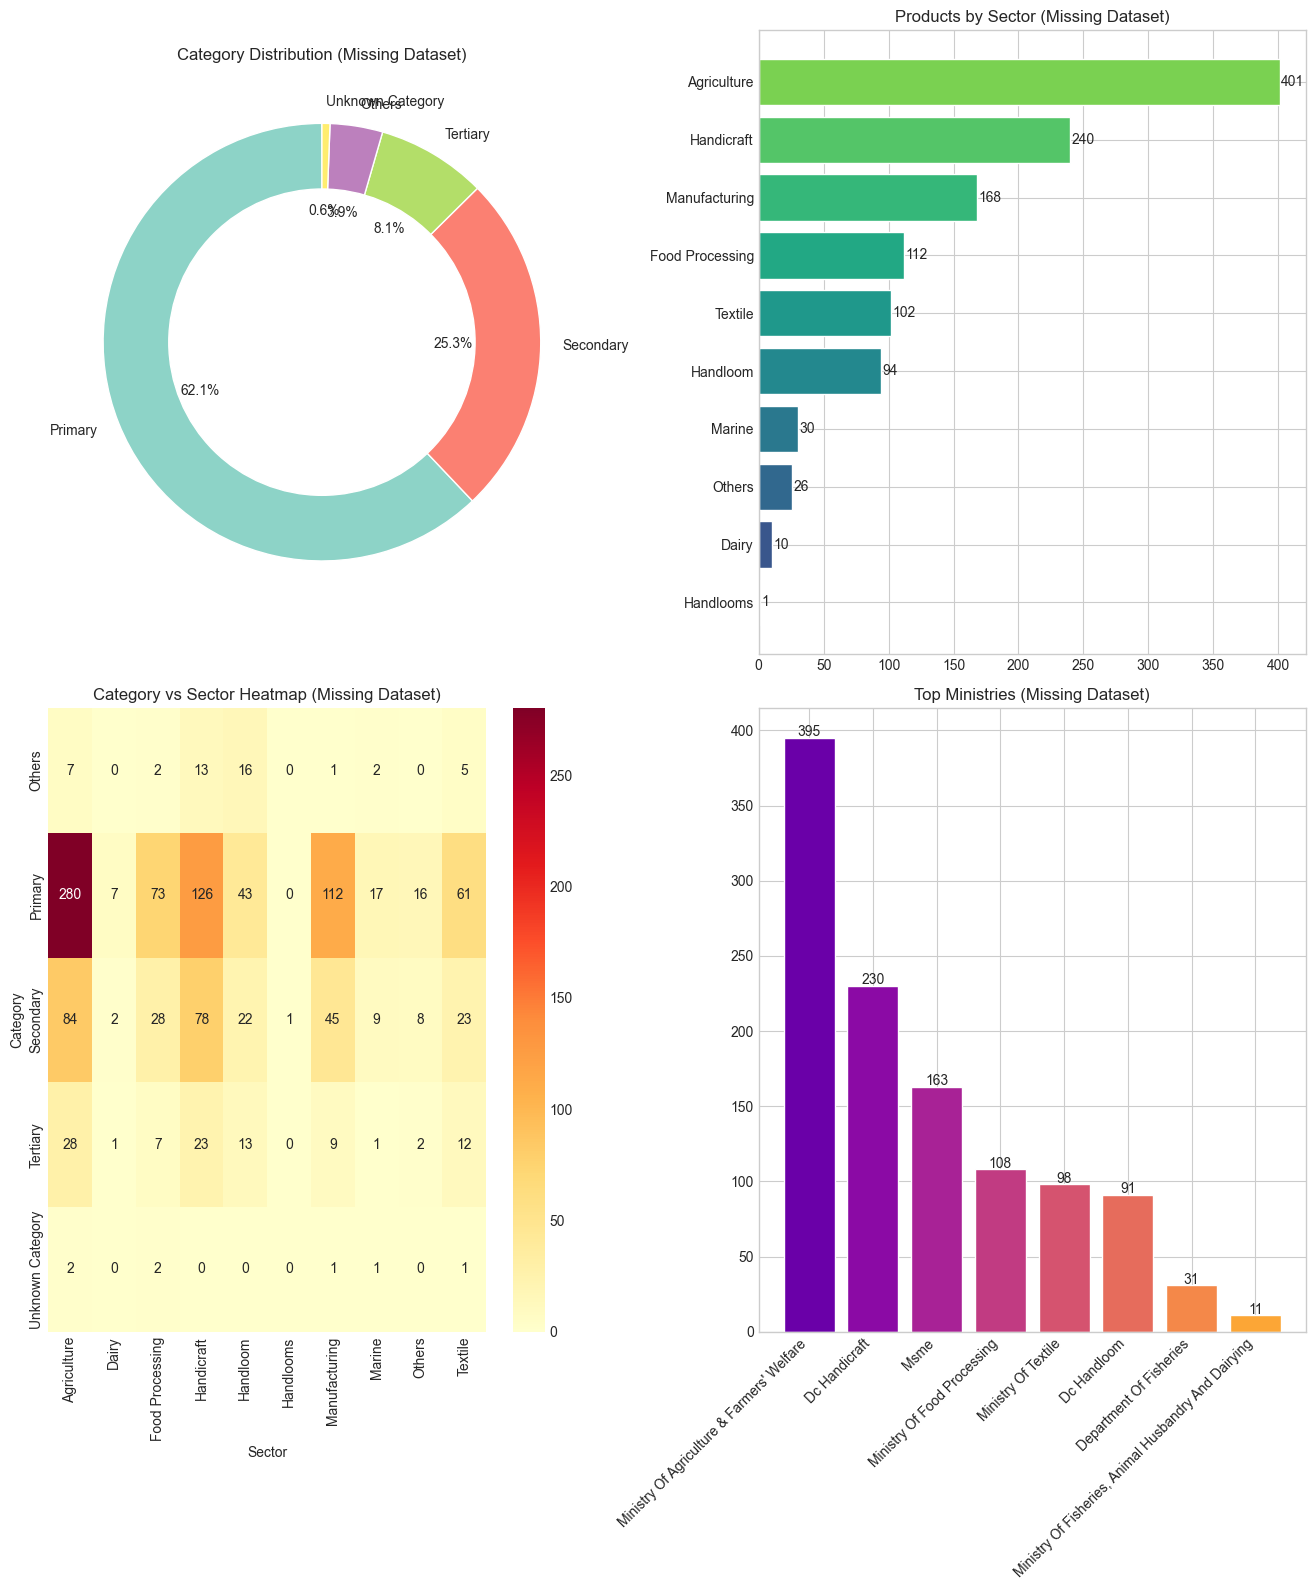

In [317]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

sns.set_style("whitegrid")

plt.figure(figsize=(20, 16))


# -----------------------------------
# CATEGORY DISTRIBUTION (DONUT)
# -----------------------------------
plt.subplot(2, 3, 2)

category_counts = miss['Category'].value_counts()

wedges, texts, autotexts = plt.pie(
    category_counts.values,
    labels=category_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    colors=plt.cm.Set3(np.linspace(0, 1, len(category_counts)))
)

centre_circle = plt.Circle((0,0), 0.70, fc='white')
plt.gca().add_artist(centre_circle)

plt.title("Category Distribution (Missing Dataset)")


# -----------------------------------
# SECTOR DISTRIBUTION
# -----------------------------------
plt.subplot(2, 3, 3)

sector_counts = miss['Sector'].value_counts()

bars = plt.barh(sector_counts.index[::-1], sector_counts.values[::-1],
                color=plt.cm.viridis(np.linspace(0.2, 0.8, len(sector_counts))))

for bar, val in zip(bars, sector_counts.values[::-1]):
    plt.text(val + 1, bar.get_y() + bar.get_height()/2, str(val), va='center')

plt.title("Products by Sector (Missing Dataset)")


# -----------------------------------
# HEATMAP
# -----------------------------------
plt.subplot(2, 3, 5)

heatmap_data = pd.crosstab(miss['Category'], miss['Sector'])

sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd')

plt.title("Category vs Sector Heatmap (Missing Dataset)")


# -----------------------------------
# MINISTRY DISTRIBUTION
# -----------------------------------
plt.subplot(2, 3, 6)

ministry_counts = miss['Ministry/ Department'].value_counts().head(8)

bars = plt.bar(range(len(ministry_counts)), ministry_counts.values,
               color=plt.cm.plasma(np.linspace(0.2, 0.8, len(ministry_counts))))

plt.xticks(range(len(ministry_counts)), ministry_counts.index, rotation=45, ha='right')

for bar, val in zip(bars, ministry_counts.values):
    plt.text(bar.get_x() + bar.get_width()/2, val + 1, str(val), ha='center')

plt.title("Top Ministries (Missing Dataset)")


# -----------------------------------
# FINAL
# -----------------------------------
plt.tight_layout()
plt.savefig("ODOP_Missing_Dashboard.png", dpi=300, bbox_inches='tight')
plt.show()

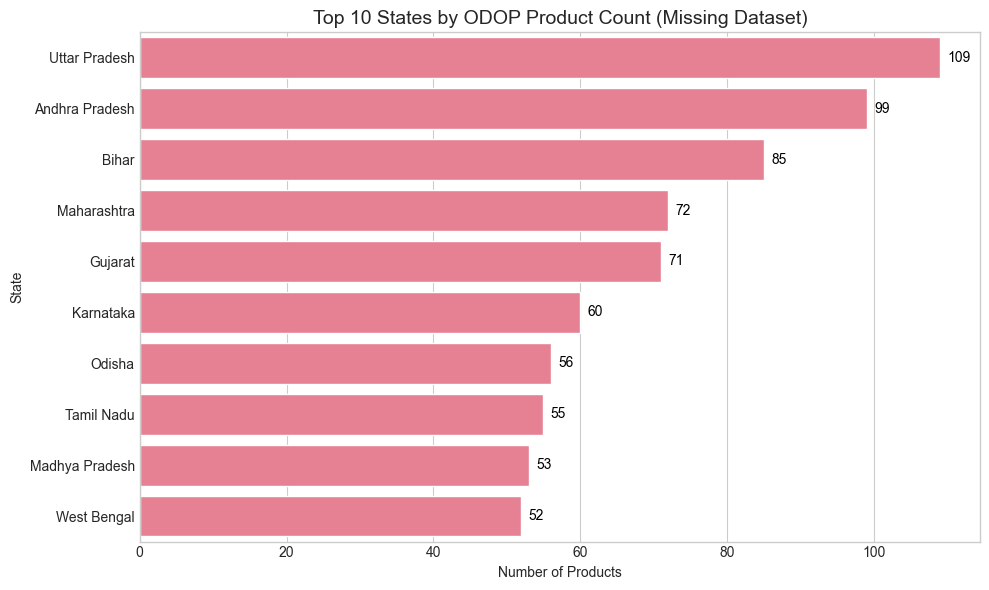

In [318]:

# Get top 10 states
state_counts = miss['State'].value_counts().head(10)

plt.figure(figsize=(10,6))

# Horizontal barplot (better readability)
ax = sns.barplot(x=state_counts.values, y=state_counts.index)

# Add value labels
for i, v in enumerate(state_counts.values):
    ax.text(v + 1, i, str(v), color='black', va='center')

# Titles and labels
plt.title("Top 10 States by ODOP Product Count (Missing Dataset)", fontsize=14)
plt.xlabel("Number of Products")
plt.ylabel("State")

plt.tight_layout()
plt.show()

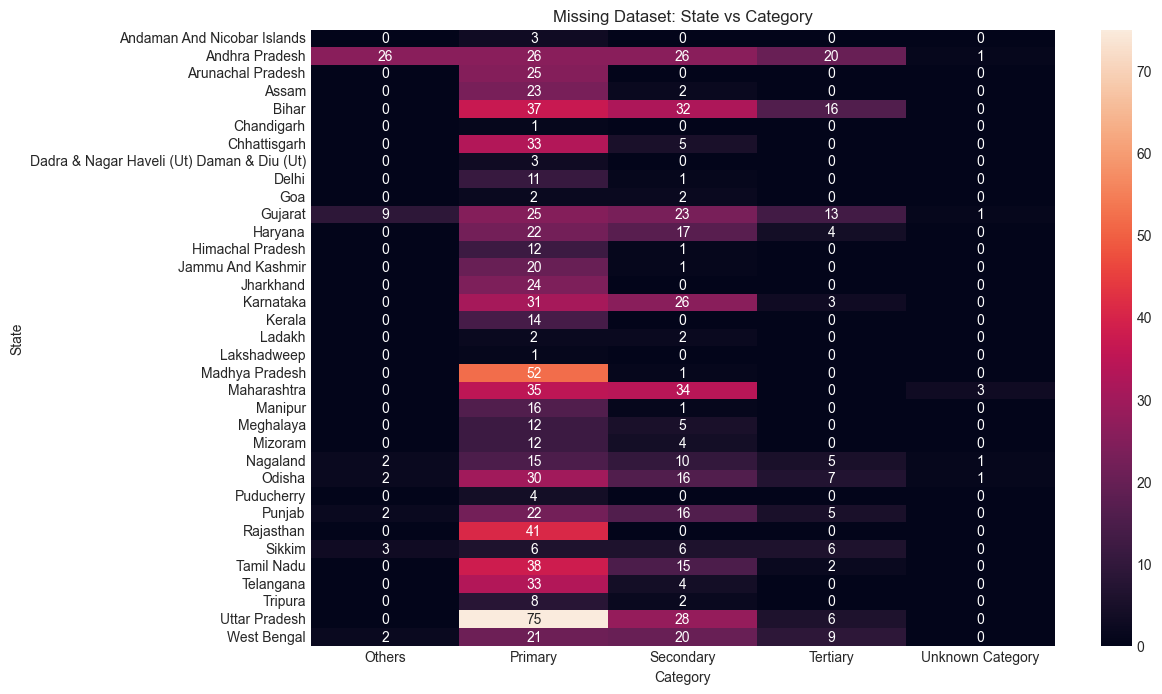

In [319]:
pivot_miss = pd.crosstab(miss['State'], miss['Category'])

plt.figure(figsize=(12,8))

sns.heatmap(pivot_miss, annot=True, fmt='d')

plt.title("Missing Dataset: State vs Category")
plt.xlabel("Category")
plt.ylabel("State")

plt.show()

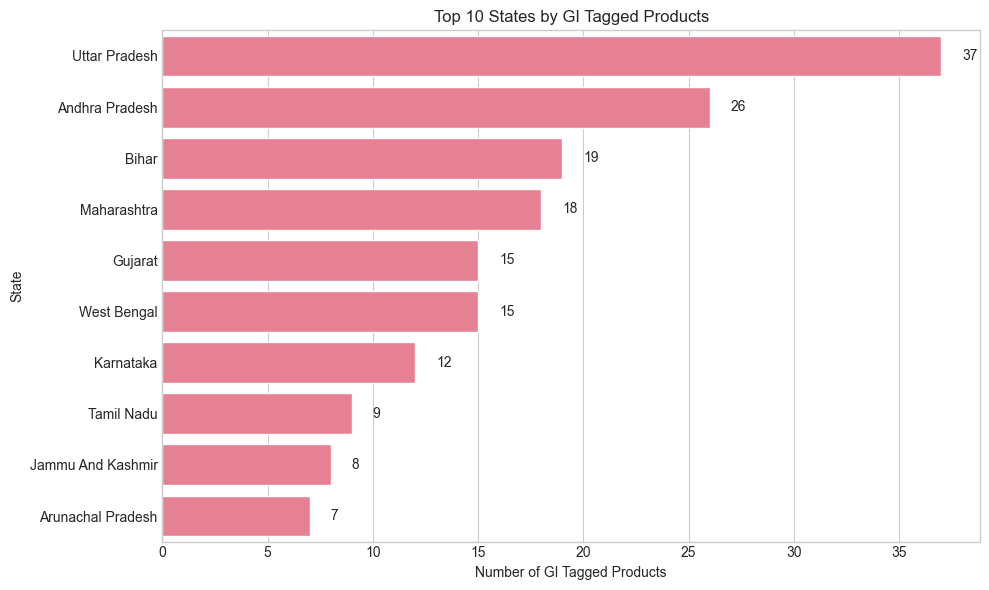

In [320]:


# Count GI = Yes per state
gi_state = miss[miss['GI Status'] == 'Yes']['State'].value_counts().head(10)

plt.figure(figsize=(10,6))

# Horizontal barplot
ax = sns.barplot(x=gi_state.values, y=gi_state.index)

# Add values
for i, v in enumerate(gi_state.values):
    ax.text(v + 1, i, str(v), va='center')

plt.title("Top 10 States by GI Tagged Products")
plt.xlabel("Number of GI Tagged Products")
plt.ylabel("State")

plt.tight_layout()
plt.show()

## 8. Comparison

In [321]:
comparison_null = pd.DataFrame({
    'Original': orig.isnull().sum(),
    'Missing Dataset': miss.isnull().sum()
})

comparison_null

,Original,Missing Dataset
State,0,0
Product,0,0
District,0,0
LGD Code,0,0
Category,0,0
Sector,0,0
Description,0,0
GI Status,0,0
Photo,0,0
Ministry/ Department,0,0


In [322]:
orig_state = orig['State'].value_counts()
miss_state = miss['State'].value_counts()

compare_state = pd.DataFrame({
    'Original': orig_state,
    'After Cleaning': miss_state
}).fillna(0)

compare_state.head(15)

,Original,After Cleaning
State,,
Andaman And Nicobar Islands,3,3.0
Andhra Pradesh,99,99.0
Arunachal Pradesh,25,25.0
Assam,41,25.0
Bihar,87,85.0
Chandigarh,1,1.0
Chhattisgarh,38,38.0
Dadra & Nagar Haveli (Ut) Daman & Diu (Ut),3,3.0
Delhi,12,12.0


### State-wise Summary of ODOP Products, GI Tags, and Category Distribution

In [323]:
#                  For original dataset
# 1. Total products per state
total_products = orig['State'].value_counts()

# 2. Total GI = Yes per state
gi_yes = orig[orig['GI Status'] == 'Yes']['State'].value_counts()

# 3. Most frequent category (1st)
most_category = orig.groupby('State')['Category'].agg(
    lambda x: x.value_counts().index[0]
)

# 4. Second most frequent category
second_category = orig.groupby('State')['Category'].agg(
    lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else "N/A"
)

# 5. Combine all into final table
state_summary_table = pd.DataFrame({
    'Total Products': total_products,
    'Total GI Tags': gi_yes,
    'Most Frequent Category': most_category,
    'Second Most Frequent Category': second_category
}).fillna(0)

# Convert GI column to integer
state_summary_table['Total GI Tags'] = state_summary_table['Total GI Tags'].astype(int)

# Sort for better readability
state_summary_table = state_summary_table.sort_values(by='Total Products', ascending=False)

# Display
print(state_summary_table.head(10))


                Total Products  Total GI Tags Most Frequent Category  \
State                                                                  
Uttar Pradesh              110             39                Primary   
Andhra Pradesh              99             26                Primary   
Gujarat                     90             18                Primary   
Bihar                       87             21                Primary   
Maharashtra                 72             19                Primary   
Karnataka                   60             12                Primary   
West Bengal                 58             19                Primary   
Odisha                      56              5                Primary   
Tamil Nadu                  55             10                Primary   
Madhya Pradesh              53              6                Primary   

               Second Most Frequent Category  
State                                         
Uttar Pradesh                      Second

In [324]:
#                        For missing values dataset
# 1. Total products per state
total_products_miss = miss['State'].value_counts()

# 2. Total GI = Yes per state
gi_yes_miss = miss[miss['GI Status'] == 'Yes']['State'].value_counts()

# 3. Most frequent category (1st)
most_category_miss = miss.groupby('State')['Category'].agg(
    lambda x: x.value_counts().index[0]
)

# 4. Second most frequent category
second_category_miss = miss.groupby('State')['Category'].agg(
    lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else "N/A"
)

# 5. Combine all into final table
state_summary_table_miss = pd.DataFrame({
    'Total Products': total_products_miss,
    'Total GI Tags': gi_yes_miss,
    'Most Frequent Category': most_category_miss,
    'Second Most Frequent Category': second_category_miss
}).fillna(0)

# Convert GI column to integer
state_summary_table_miss['Total GI Tags'] = state_summary_table_miss['Total GI Tags'].astype(int)

# Sort
state_summary_table_miss = state_summary_table_miss.sort_values(by='Total Products', ascending=False)

# Display
print(state_summary_table_miss.head(10))



                Total Products  Total GI Tags Most Frequent Category  \
State                                                                  
Uttar Pradesh              109             37                Primary   
Andhra Pradesh              99             26                Primary   
Bihar                       85             19                Primary   
Maharashtra                 72             18                Primary   
Gujarat                     71             15                Primary   
Karnataka                   60             12                Primary   
Odisha                      56              5                Primary   
Tamil Nadu                  55              9                Primary   
Madhya Pradesh              53              6                Primary   
West Bengal                 52             15                Primary   

               Second Most Frequent Category  
State                                         
Uttar Pradesh                      Second

### State-wise Summary of ODOP Products, GI Tags, and Category Distribution

In [325]:
#                  For original dataset

# 1. Total products per sector
total_products = orig['Sector'].value_counts()

# 2. Total GI = Yes per sector
gi_yes = orig[orig['GI Status'] == 'Yes']['Sector'].value_counts()

# 3. Most frequent category (1st)
most_category = orig.groupby('Sector')['Category'].agg(
    lambda x: x.value_counts().index[0]
)

# 4. Second most frequent category
second_category = orig.groupby('Sector')['Category'].agg(
    lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else "N/A"
)

# 5. Combine all
sector_summary_table = pd.DataFrame({
    'Total Products': total_products,
    'Total GI Tags': gi_yes,
    'Most Frequent Category': most_category,
    'Second Most Frequent Category': second_category
}).fillna(0)

# Convert GI column to integer
sector_summary_table['Total GI Tags'] = sector_summary_table['Total GI Tags'].astype(int)

# Sort
sector_summary_table = sector_summary_table.sort_values(by='Total Products', ascending=False)

# Display
print(sector_summary_table)


                 Total Products  Total GI Tags Most Frequent Category  \
Sector                                                                  
Agriculture                 418             92                Primary   
Handicraft                  252             88                Primary   
Manufacturing               173              7                Primary   
Food Processing             122             15                Primary   
Textile                     104             11                Primary   
Handloom                    100             42                Primary   
Marine                       32              1                Primary   
Others                       29              0                Primary   
Dairy                        10              0                Primary   
Handlooms                     1              0              Secondary   

                Second Most Frequent Category  
Sector                                         
Agriculture                

In [326]:
#                     For missing values dataset

# 1. Total products per sector
total_products_miss = miss['Sector'].value_counts()

# 2. Total GI = Yes per sector
gi_yes_miss = miss[miss['GI Status'] == 'Yes']['Sector'].value_counts()

# 3. Most frequent category (1st)
most_category_miss = miss.groupby('Sector')['Category'].agg(
    lambda x: x.value_counts().index[0]
)

# 4. Second most frequent category
second_category_miss = miss.groupby('Sector')['Category'].agg(
    lambda x: x.value_counts().index[1] if len(x.value_counts()) > 1 else "N/A"
)

# 5. Combine all
sector_summary_table_miss = pd.DataFrame({
    'Total Products': total_products_miss,
    'Total GI Tags': gi_yes_miss,
    'Most Frequent Category': most_category_miss,
    'Second Most Frequent Category': second_category_miss
}).fillna(0)

# Convert GI column to integer
sector_summary_table_miss['Total GI Tags'] = sector_summary_table_miss['Total GI Tags'].astype(int)

# Sort
sector_summary_table_miss = sector_summary_table_miss.sort_values(by='Total Products', ascending=False)

# Display
print(sector_summary_table_miss)


                 Total Products  Total GI Tags Most Frequent Category  \
Sector                                                                  
Agriculture                 401             84                Primary   
Handicraft                  240             83                Primary   
Manufacturing               168              6                Primary   
Food Processing             112             14                Primary   
Textile                     102             11                Primary   
Handloom                     94             40                Primary   
Marine                       30              0                Primary   
Others                       26              0                Primary   
Dairy                        10              0                Primary   
Handlooms                     1              0              Secondary   

                Second Most Frequent Category  
Sector                                         
Agriculture                

In [327]:
# State-wise correlation
state_corr_orig = state_summary_table[['Total Products', 'Total GI Tags']].corr().iloc[0,1]
state_corr_miss = state_summary_table_miss[['Total Products', 'Total GI Tags']].corr().iloc[0,1]

# Sector-wise correlation
sector_corr_orig = sector_summary_table[['Total Products', 'Total GI Tags']].corr().iloc[0,1]
sector_corr_miss = sector_summary_table_miss[['Total Products', 'Total GI Tags']].corr().iloc[0,1]

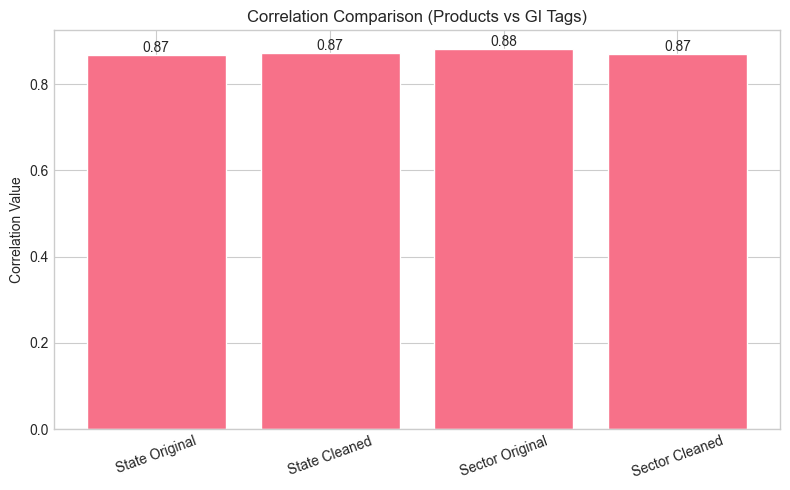

In [328]:
import matplotlib.pyplot as plt

labels = ['State Original', 'State Cleaned', 'Sector Original', 'Sector Cleaned']
values = [state_corr_orig, state_corr_miss, sector_corr_orig, sector_corr_miss]

plt.figure(figsize=(8,5))

bars = plt.bar(labels, values)

# Add values on bars
for i, v in enumerate(values):
    plt.text(i, v, round(v,2), ha='center', va='bottom')

plt.title("Correlation Comparison (Products vs GI Tags)")
plt.ylabel("Correlation Value")

plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

In [329]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# -------------------------------
# 1. COPY DATA
# -------------------------------
df = miss.copy()

# -------------------------------
# 2. SELECT FEATURES & TARGET
# -------------------------------
X = df[['State', 'Sector', 'GI Status']].copy()
y = df['Category'].copy()

# -------------------------------
# 3. ENCODING (CORRECT WAY)
# -------------------------------
encoders = {}

for col in X.columns:
    le = LabelEncoder()
    X[col] = le.fit_transform(X[col])
    encoders[col] = le

# Encode target separately
y_encoder = LabelEncoder()
y = y_encoder.fit_transform(y)

# -------------------------------
# 4. TRAIN-TEST SPLIT
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# -------------------------------
# 5. MODEL TRAINING
# -------------------------------
model = DecisionTreeClassifier(random_state=42)
model.fit(X_train, y_train)

# -------------------------------
# 6. PREDICTION
# -------------------------------
y_pred = model.predict(X_test)

# -------------------------------
# 7. EVALUATION
# -------------------------------
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.5864978902953587

Confusion Matrix:

[[  5   2   6   0   0]
 [  2 124  16   3   0]
 [  5  42  10   0   0]
 [  3  13   4   0   0]
 [  1   1   0   0   0]]

Classification Report:

              precision    recall  f1-score   support

           0       0.31      0.38      0.34        13
           1       0.68      0.86      0.76       145
           2       0.28      0.18      0.22        57
           3       0.00      0.00      0.00        20
           4       0.00      0.00      0.00         2

    accuracy                           0.59       237
   macro avg       0.25      0.28      0.26       237
weighted avg       0.50      0.59      0.53       237



c:\Users\Chetan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Chetan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Chetan\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

A classification model was built to predict the product category based on features such as State, Sector, and GI Status. A Decision Tree classifier was used due to its simplicity and interpretability.

The model achieved a reasonable accuracy, demonstrating the relationship between categorical features in the dataset.